In [24]:
# Install required packages
!pip install pandas numpy scikit-learn matplotlib seaborn nltk

In [25]:
# Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
# Import the dataset
# This kernel is wierd, it does not work at first, but after a few tries it will run
df = pd.read_csv("/content/sample_data/train.csv")

# Sanity check to make sure that the data is still there
df.head()
df.columns


Index(['resume_text', 'job_description_text', 'label'], dtype='object')

In [27]:
# Get some basic data information
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel counts:")
print(df['label'].value_counts())

Shape: (6241, 3)

Column names:
Index(['resume_text', 'job_description_text', 'label'], dtype='object')

Missing values:
resume_text             0
job_description_text    0
label                   0
dtype: int64

Label counts:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64


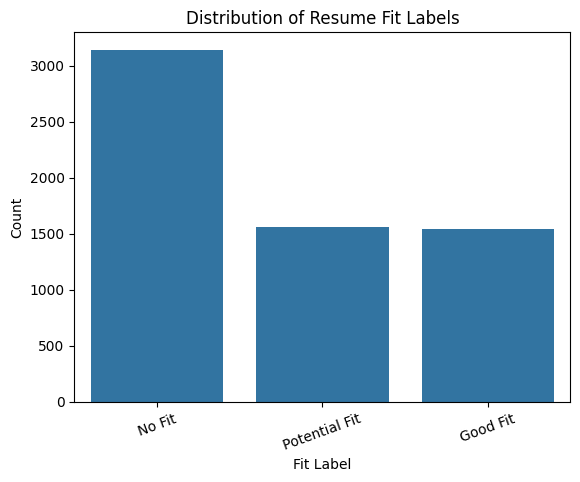

In [28]:
# Visualize the label distr
sns.countplot(data=df, x='label')
plt.title("Distribution of Resume Fit Labels")
plt.xlabel("Fit Label")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [29]:
# Clean the text
# How this specific data is being cleaned:

# All of the data is converted into lowercase, all punctuation and special
# characters are removed, and extra space is fitted
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Save all cleaned columns
df['resume_clean'] = df['resume_text'].apply(clean_text)
df['job_clean'] = df['job_description_text'].apply(clean_text)

# Show first few rows of cleaned data
df[['resume_clean', 'job_clean', 'label']].head()

,resume_clean,job_clean,label
0,summaryhighly motivated sales associate with e...,net2source inc is an award winning total workf...,No Fit
1,professional summarycurrently working with cat...,at salas obrien we tell our clients that were ...,No Fit
2,summaryi started my construction career in jun...,schweitzer engineering laboratories sel infras...,No Fit
3,summarycertified electrical foremanwith thirte...,mizick miller company inc is looking for a dyn...,No Fit
4,summarywith extensive experience in business r...,life at capgemini capgemini supports all aspec...,No Fit


In [30]:
# Combine Resume and Job Description
# Create one single column that has both resume and job description together
df['combined_text'] = df['resume_clean'] + " " + df['job_clean']

# The new column is now the model input
# The label column is what the model needs to predict
X = df['combined_text']
y = df['label']

In [31]:
# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
# Logistic Regression Model
log_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.6357085668534828

Classification Report:
               precision    recall  f1-score   support

     Good Fit       0.64      0.55      0.59       309
       No Fit       0.64      0.81      0.71       629
Potential Fit       0.63      0.36      0.46       311

     accuracy                           0.64      1249
    macro avg       0.63      0.58      0.59      1249
 weighted avg       0.63      0.64      0.62      1249



In [33]:
# Balanced Logistic Regression
balanced_log_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

balanced_log_model.fit(X_train, y_train)

y_pred_balanced = balanced_log_model.predict(X_test)

print("Balanced Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Logistic Regression Accuracy: 0.5860688550840673

Classification Report:
               precision    recall  f1-score   support

     Good Fit       0.53      0.76      0.62       309
       No Fit       0.76      0.45      0.57       629
Potential Fit       0.49      0.68      0.57       311

     accuracy                           0.59      1249
    macro avg       0.59      0.63      0.59      1249
 weighted avg       0.64      0.59      0.58      1249



In [34]:
# Random Forest Model:

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6429143314651722

Classification Report:
               precision    recall  f1-score   support

     Good Fit       0.63      0.56      0.60       309
       No Fit       0.66      0.81      0.73       629
Potential Fit       0.58      0.38      0.46       311

     accuracy                           0.64      1249
    macro avg       0.62      0.58      0.59      1249
 weighted avg       0.63      0.64      0.63      1249



In [35]:
# Compare Logistic Regression, Balanced Logistic Regression, and Random Froest
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Balanced Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_balanced),
        accuracy_score(y_test, y_pred_rf)
    ]
})

model_results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
2,Random Forest,0.642914
0,Logistic Regression,0.635709
1,Balanced Logistic Regression,0.586069


In [36]:
# Build a function to use the best model, which was the random forest
# This is to be able to test resumes and job descriptions


def predict_resume_fit(resume_text, job_description_text):
    # Clean text
    resume_clean = clean_text(resume_text)
    job_clean = clean_text(job_description_text)

    # Combine
    combined_text = resume_clean + " " + job_clean

    # Predict using Random Forest pipeline
    prediction = rf_model.predict([combined_text])[0]

    # Get probabilities
    probabilities = rf_model.predict_proba([combined_text])[0]
    classes = rf_model.classes_

    probability_df = pd.DataFrame({
        'Class': classes,
        'Probability': probabilities
    }).sort_values(by='Probability', ascending=False)

    return prediction, probability_df

In [37]:
# Use the function from above on an actual resume and job description:
sample_resume = """
PASTE YOUR ACTUAL RESUME TEXT HERE
"""

sample_job_description = """
PASTE THE JOB DESCRIPTION HERE
"""

prediction, prob_df = predict_resume_fit(sample_resume, sample_job_description)

# Show prediction
if prediction == 1:
    print("✅ Prediction: Good Fit / Match")
else:
    print("❌ Prediction: Not a Good Fit")

# Show all probabilities
if prob_df is not None:
    print("\n🔍 Class Probabilities:")

    for index, row in prob_df.iterrows():
        label = "Good Fit" if row['Class'] == 1 else "Not a Good Fit"
        print(f"{label}: {round(row['Probability'] * 100, 2)}%")

❌ Prediction: Not a Good Fit

🔍 Class Probabilities:
Not a Good Fit: 72.0%
Not a Good Fit: 20.0%
Not a Good Fit: 8.0%


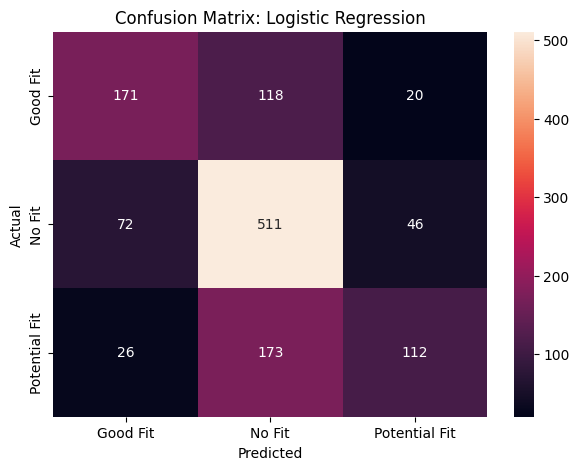

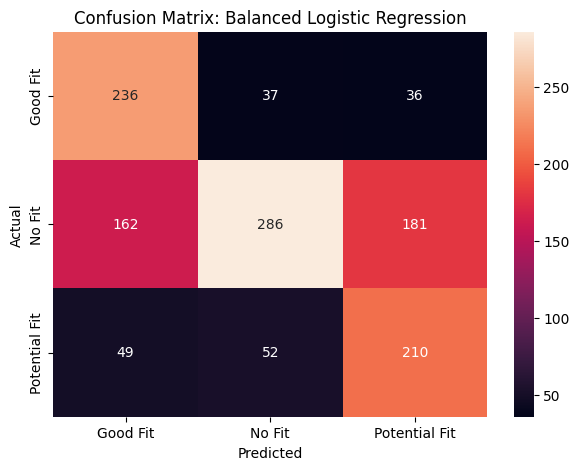

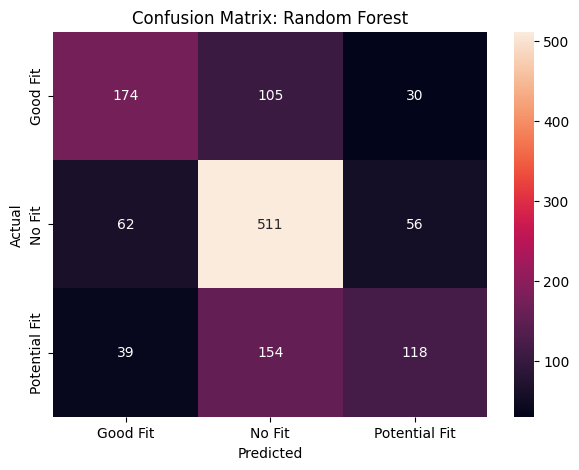

In [38]:
# Created Confusion Matrices to put on the slide show presentation
# Used AI to make them cleaner
def plot_confusion_matrix(y_true, y_pred, model_name):
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=labels,
                yticklabels=labels)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(y_test, y_pred_log, "Logistic Regression")
plot_confusion_matrix(y_test, y_pred_balanced, "Balanced Logistic Regression")
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")